# Replogle K562: compact four-panel figure

This notebook reads saved results only.
Run `python -m experiments.replogle.run` first to reproduce the analysis.
Panels (a) and (b) compare pair-level RMSE against the all-data raw-difference reference, which is an empirical reference rather than causal ground truth.
Panels (c) and (d) show the same fixed gene panel and perturbation order.
RCB effects are differences of mean log1p expression divided by ln(2), as in the original figure notebook; Wilcoxon values are the supplied log2 fold changes, so the quantities are distinct.
Stars in (c) mark shifted model-based prediction intervals excluding zero, not ATT confidence intervals; stars in (d) mark adjusted Wilcoxon p-values below 0.05.
The color range is fixed at -3 to 3, with out-of-range values clipped.


In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
from rcb import paths

OUTPUT = paths.results("replogle", create=False)
FIGURES = paths.figures("replogle")
manifest_path = OUTPUT / "run_manifest.json"
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text())
    if manifest["status"] != "complete":
        raise RuntimeError("Replogle run is incomplete; regenerate results before plotting")
    print("Results mode:", manifest["mode"])
else:
    print("Reading supplied reference results; generating configuration is not recorded.")
att_summary = pd.read_csv(OUTPUT / "att_overlap_tilt_pair_summary.csv")
full = pd.read_csv(OUTPUT / "full_k562_rcb_analysis.csv")
genes = pd.read_csv(OUTPUT / "full_k562_outcome_panel.csv")["outcome_h"].tolist()
perturbations = full["perturbation_p"].drop_duplicates().tolist()
for column in ("rcb_interval_excludes_zero", "de_significant"):
    full[column] = full[column].astype(str).str.lower().eq("true")
plot_df = att_summary.loc[att_summary["reference_type"] == "All-data raw difference"]
pairs = [
    ("Uniform", "pure_uniform", "rcb_uniform"),
    ("L2", "pure_l2", "rcb_l2"),
    ("Entropy", "pure_entropy", "rcb_entropy"),
    ("ABW\nOutcome", "double_ridge_outcome", "rcb_on_abw_outcome"),
    ("ABW\nImbalance", "double_ridge_imbalance", "rcb_on_abw_imbalance"),
    ("ABW\nRiesz", "double_ridge_riesz", "rcb_on_abw_riesz"),
]


Reading supplied reference results; generating configuration is not recorded.


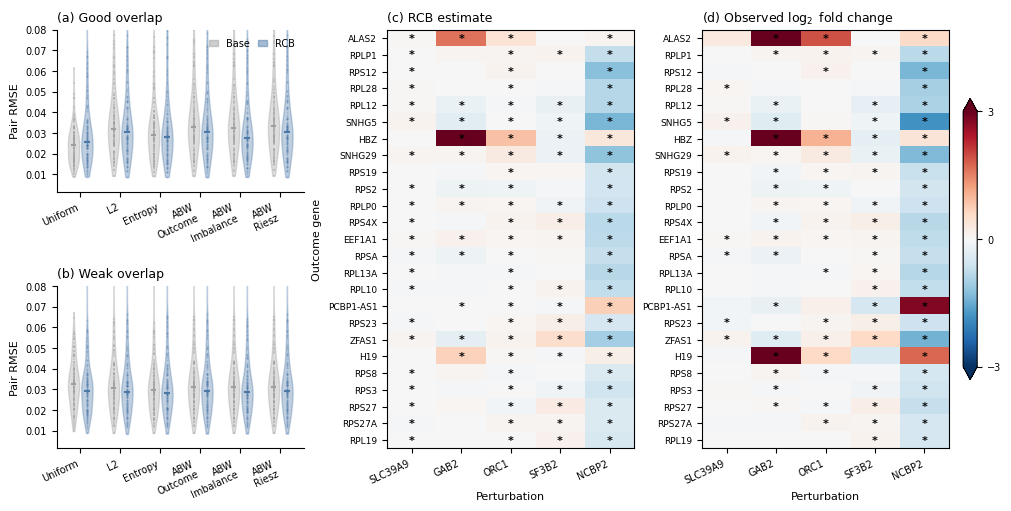

In [2]:
with plt.rc_context({"font.size": 10, "axes.titlesize": 9, "axes.labelsize": 8,
                     "xtick.labelsize": 7, "ytick.labelsize": 7, "pdf.fonttype": 42}):
    fig = plt.figure(figsize=(10, 5), layout="constrained")
    gs = fig.add_gridspec(2, 3, width_ratios=[1, 1., 1.])
    ax_a = fig.add_subplot(gs[0, 0])
    ax_b = fig.add_subplot(gs[1, 0])
    ax_c = fig.add_subplot(gs[:, 1])
    ax_d = fig.add_subplot(gs[:, 2])

    colors = ("#9E9E9E", "#4C78A8")
    for ax, regime, panel in zip((ax_a, ax_b), ("good", "weak"), ("a", "b")):
        subset = plot_df.loc[plot_df["regime"] == regime]
        for i, (_, base_key, rcb_key) in enumerate(pairs):
            for offset, key, color, marker in zip((1, 2), (base_key, rcb_key), colors, ("s", "o")):
                values = subset.loc[subset["method_key"] == key, "rmse"].to_numpy(float)
                if not len(values) or not np.isfinite(values).all() or np.any(values <= 0):
                    raise ValueError(f"Missing or nonpositive RMSE for {regime}/{key}")
                position = 3 * i + offset
                if len(values) > 1 and np.ptp(values) > 0:
                    violin = ax.violinplot([values], positions=[position], widths=0.85,
                                           showmedians=True, showextrema=False)
                    violin["bodies"][0].set_facecolor(color)
                    violin["bodies"][0].set_edgecolor(color)
                    violin["bodies"][0].set_alpha(0.35)
                    violin["cmedians"].set_color(color)
                ax.scatter(np.full(len(values), position), values, s=2, alpha=0.3,
                    color=color, marker=marker, linewidths=0)
        ax.set_xticks([3 * i + 1.5 for i in range(len(pairs))], [p[0] for p in pairs],
                      rotation=25, ha="right")
        ax.set_ylabel("Pair RMSE")    
        ax.set_title(f"({panel}) {regime.capitalize()} overlap", loc="left")
        ax.spines[["top", "right"]].set_visible(False)
    limits = (min(ax.get_ylim()[0] for ax in (ax_a, ax_b)), 
              0.08)#max(ax.get_ylim()[1] for ax in (ax_a, ax_b)))
    for ax in (ax_a, ax_b):
        ax.set_ylim(limits)
    ax_a.legend(handles=[Patch(color=c, alpha=0.5, label=l)
                          for c, l in zip(colors, ("Base", "RCB"))],
                loc="upper right", frameon=False, ncol=2, fontsize=7,
                handlelength=1, columnspacing=0.8)

    norm = TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)
    for ax, value, flag, scale, title in (
        (ax_c, "rcb_effect", "rcb_interval_excludes_zero", np.log(2), "(c) RCB predictive contrast"),
        (ax_d, "de_logFC", "de_significant", 1, r"(d) Observed $\log_2$ fold change"),
    ):
        matrix = full.pivot(index="outcome_h", columns="perturbation_p", values=value).reindex(index=genes, columns=perturbations) / scale
        flags = full.pivot(index="outcome_h", columns="perturbation_p", values=flag).reindex(index=genes, columns=perturbations)
        if matrix.isna().any().any() or flags.isna().any().any():
            raise ValueError("Incomplete fixed-panel result matrix")
        im = ax.imshow(np.clip(matrix.to_numpy(float), -3, 3), aspect="auto", cmap="RdBu_r", norm=norm)
        ax.set_xticks(range(len(perturbations)), perturbations, rotation=25, ha="right")
        ax.set_yticks(range(len(genes)), genes, fontsize=6.5)
        ax.set_xlabel("Perturbation")
        ax.set_title(title, loc="left")
        for i, j in np.argwhere(flags.to_numpy(bool)):
            ax.text(j, i, "*", ha="center", va="center", fontsize=8, fontweight="bold")
    ax_c.set_ylabel("Outcome gene")
    fig.colorbar(im, ax=[ax_c, ax_d], fraction=0.025, pad=0.025, ticks=[-3, 0, 3], extend="both")
    figure_path = FIGURES / "01_k562_overview.pdf"
    fig.savefig(figure_path, bbox_inches="tight")
    plt.show()
